### 1. Data load 및 데이터 파악

In [193]:
# 자료를 가져온다.
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits

In [194]:
# 불러온 digits 데이터를 확인한다.
digits = load_digits()
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [196]:
# digits의 keys를 확인한다.
print("Keys of digits:\n", digits.keys())

Keys of digits:
 dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [197]:
# digits의 shape을 확인한다.
print("Shape of data:", digits['data'].shape) 
print(digits['data'])

Shape of data: (1797, 64)
[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


In [186]:
# digits의 feature를 출력하고 갯수를 센다. 총 64개로 이루어져 있다.
print("Feature names:\n", digits['feature_names'])
print("len of feature_names:", len(digits['feature_names']))

Feature names:
 ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']
len of feature_names: 64


In [188]:
# digits의 target_names를 출력해본다. target은 0~9까지의 숫자로 이루어져 있다.
print("Target names:", digits['target_names'])
print("Shape of target class:", digits['target_names'].shape)

Target names: [0 1 2 3 4 5 6 7 8 9]
Shape of target class: (10,)


[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


<Figure size 432x288 with 0 Axes>

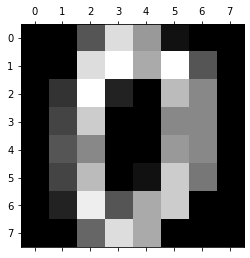

In [199]:
# 첫번째 image가 어떻게 이루어져 있는지 확인해본다. (8x8의 배열로 이루어져있다.)
print(digits['images'][0])

import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[0])

plt.show()

## 2. 전처리

In [175]:
# 먼저 결측치가 있는지 본다. 결측치는 없다.
pd.isnull(digits) 

False

In [206]:
# images를 flattening하여 1차원 벡터로 바꿔준다.
print(digits['images'].shape)

images = digits.images
images = images.reshape(images.shape[0],-1)

print(images[0])
print(images.shape)

(1797, 8, 8)
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
(1797, 64)


## 3. learning algorithm

### (1) kNN

In [243]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [241]:
# train_test_split 함수를 이용해 데이터를 분할해준다.
X_train, X_test, y_train, y_test = train_test_split(images, digits.target,random_state=42)

In [290]:
# hyperparameter 설정: k값을 다르게 해서 정확도를 측정한다.
k_values = [3,5,7,10,20]
weights_options = ['uniform', 'distance']  # 가중치 옵션 설정
results = {}

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[(k)] = accuracy

for params, accuracy in results.items():
    print(f"K: {params}, Accuracy: {accuracy}")
    
from sklearn.metrics import precision_score

# KNN 모델의 정밀도 계산
knn_precision = precision_score(y_test, y_pred, average='weighted')
print(knn_precision)

from sklearn.metrics import f1_score

knn_f1 = f1_score(y_test, y_pred, average='weighted')
print(knn_f1)

K: 3, Accuracy: 0.9866666666666667
K: 5, Accuracy: 0.9933333333333333
K: 7, Accuracy: 0.9933333333333333
K: 10, Accuracy: 0.9866666666666667
K: 20, Accuracy: 0.9777777777777777
[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8 4 3 9 7 5 6 3 5 6 3 4 9 1 4 4 6 9
 4 7 6 6 9 1 3 6 1 3 0 6 5 5 1 9 5 6 0 9 0 0 1 0 4 5 2 4 5 7 0 7 5 9 9 5 4
 7 0 4 5 5 9 9 0 2 3 8 0 6 4 4 9 1 2 8 3 5 2 9 0 4 4 4 3 5 3 1 3 5 9 4 2 7
 7 4 4 1 9 2 7 8 7 2 6 9 4 0 7 2 7 5 8 7 5 7 7 0 6 6 4 2 8 0 9 4 6 9 9 6 9
 0 3 5 6 6 0 6 4 3 9 3 7 7 2 9 0 4 5 3 6 5 7 9 8 4 2 1 3 7 7 2 2 3 9 8 0 3
 2 2 5 6 9 9 4 1 5 4 2 3 6 4 8 5 9 5 7 1 9 4 8 1 5 4 4 9 6 1 8 6 0 4 5 2 7
 4 6 4 5 6 0 3 2 3 6 7 1 9 1 4 7 6 8 1 5 5 1 6 2 8 8 9 5 7 6 2 2 2 3 4 8 8
 3 6 0 9 7 7 0 1 0 4 5 1 5 3 6 0 4 1 0 0 3 6 5 9 7 3 5 5 9 9 8 5 3 3 2 0 5
 8 3 4 0 2 4 6 4 3 4 5 0 5 2 1 3 1 4 1 1 7 0 1 5 2 1 2 8 7 0 6 4 8 8 5 1 8
 4 5 8 7 9 8 6 0 6 2 0 7 9 1 9 5 2 7 7 1 8 7 4 3 8 3 5 6 0 0 3 0 5 0 0 4 1
 2 8 4 5 9 6 3 1 8 8 4 2 3 8 9 8 8 5 0 6 3 3 7 1 6 4 1 2 1 1 6 4 7 4 8 3 

### (2) Decision Tree

In [247]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [255]:
# train_test_split 함수를 이용해 데이터를 분할해준다.
X_train, X_test, y_train, y_test = train_test_split(images, digits.target,random_state=42)

In [257]:
#training 정확도와 validation 정확도를 저장하기 위해 빈 리스트를 생성해준다.
from sklearn.metrics import accuracy_score
training_accuracy = []
val_accuracy = []

In [284]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 테스트할 하이퍼파라미터 값들
min_samples_leaf_values = [1, 5, 10]
max_depth_values = [None, 5, 10]

results = {}

for min_samples_leaf in min_samples_leaf_values:
    for max_depth in max_depth_values:
        # Decision Tree 모델 생성
        dt_clf = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf, max_depth=max_depth, random_state=42)
        # 모델 학습
        dt_clf.fit(X_train, y_train)
        # 예측
        y_pred = dt_clf.predict(X_test)
        # 정확도 측정
        accuracy = accuracy_score(y_test, y_pred)
        # 결과 저장
        results[(min_samples_leaf, max_depth)] = accuracy

# 결과 출력
for params, accuracy in results.items():
    print(f"min_samples_leaf: {params[0]}, max_depth: {params[1]} - Accuracy: {accuracy}")

# Decision Tree 모델의 정밀도 계산
tree_precision = precision_score(y_test, y_pred, average='weighted')
print(tree_precision)

tree_f1 = f1_score(y_test, y_pred, average='weighted')
print(tree_f1)

min_samples_leaf: 1, max_depth: None - Accuracy: 0.8577777777777778
min_samples_leaf: 1, max_depth: 5 - Accuracy: 0.6688888888888889
min_samples_leaf: 1, max_depth: 10 - Accuracy: 0.8666666666666667
min_samples_leaf: 5, max_depth: None - Accuracy: 0.8755555555555555
min_samples_leaf: 5, max_depth: 5 - Accuracy: 0.6711111111111111
min_samples_leaf: 5, max_depth: 10 - Accuracy: 0.8733333333333333
min_samples_leaf: 10, max_depth: None - Accuracy: 0.84
min_samples_leaf: 10, max_depth: 5 - Accuracy: 0.6711111111111111
min_samples_leaf: 10, max_depth: 10 - Accuracy: 0.84
0.8509410116965888
0.8406348083799509


### (3)  Random Forest

In [263]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [293]:
# 테스트할 하이퍼파라미터 값들
n_estimators_values = [50, 100, 150]
max_depth_values = [10, 20, 30]

results = {}

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        rf_clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        rf_clf.fit(X_train, y_train)
        # 예측
        y_pred = rf_clf.predict(X_test)
        # 정확도 측정
        accuracy = accuracy_score(y_test, y_pred)
        # 결과 저장
        results[(n_estimators, max_depth)] = accuracy

# 결과 출력
for params, accuracy in results.items():
    print(f"n_estimators: {params[0]}, max_depth: {params[1]} - Accuracy: {accuracy}")
    
# Random Forest 모델의 정밀도 계산
rf_precision = precision_score(y_test, y_pred, average='weighted')
print(rf_precision)

rf_f1 = f1_score(y_test, y_pred, average='weighted')
print(rf_f1)

n_estimators: 50, max_depth: 10 - Accuracy: 0.9755555555555555
n_estimators: 50, max_depth: 20 - Accuracy: 0.9711111111111111
n_estimators: 50, max_depth: 30 - Accuracy: 0.9711111111111111
n_estimators: 100, max_depth: 10 - Accuracy: 0.9733333333333334
n_estimators: 100, max_depth: 20 - Accuracy: 0.9711111111111111
n_estimators: 100, max_depth: 30 - Accuracy: 0.9711111111111111
n_estimators: 150, max_depth: 10 - Accuracy: 0.9755555555555555
n_estimators: 150, max_depth: 20 - Accuracy: 0.9733333333333334
n_estimators: 150, max_depth: 30 - Accuracy: 0.9733333333333334
n_estimators: 400, max_depth: 10 - Accuracy: 0.9755555555555555
n_estimators: 400, max_depth: 20 - Accuracy: 0.9733333333333334
n_estimators: 400, max_depth: 30 - Accuracy: 0.9733333333333334
0.9737120472120472
0.9733230767703234


## 4. 최적의 learning algorithm 선택

In [272]:
from sklearn.metrics import precision_score

# KNN 모델의 정밀도 계산
knn_precision = precision_score(y_test, knn_pred, average='weighted')

# Decision Tree 모델의 정밀도 계산
tree_precision = precision_score(y_test, tree_pred, average='weighted')

# Random Forest 모델의 정밀도 계산
rf_precision = precision_score(y_test, rf_pred, average='weighted')

print("KNN 모델의 정밀도:", knn_precision)
print("Decision Tree 모델의 정밀도:", tree_precision)
print("Random Forest 모델의 정밀도:", rf_precision)

NameError: name 'knn_pred' is not defined

In [ ]:
from sklearn.metrics import f1_score

# KNN 모델의 F1-score 계산
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

# Decision Tree 모델의 F1-score 계산
tree_f1 = f1_score(y_test, tree_pred, average='weighted')

# Random Forest 모델의 F1-score 계산
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("KNN 모델의 F1-score:", knn_f1)
print("Decision Tree 모델의 F1-score:", tree_f1)
print("Random Forest 모델의 F1-score:", rf_f1)